# Grid Experiments

Runs the full pipeline (sampling → processing → HCC → words/POU) for all combinations of
grid size and district count defined in `CONFIGS` below.

## Config

In [6]:
# (grid_size N, num_districts k)
CONFIGS = [
    (4, 2), (6, 2), (8, 2), (10, 2), (12, 2), (14, 2), (16, 2), (18, 2), (20, 2)
]

CYCLE_WALK_STEPS = "1e5"
POP_DEV          = 0.1
MAX_SAMPLES      = 1000
MIN_STEP         = 100
NUM_LETTERS      = 20
WORD_DEGREE      = 10
TEMP             = 0.0

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_graph, generate_grid_shape
from hierachical import HClusters
from sample import SampleProcessor
from utils import plot_words_list
from word import PlanWordBuilder, WordStat


def graph_fn(N, k):   return f"data/graph/grid_{N}x{N}_k{k}.json"
def sample_fn(N, k):  return f"local/output/grid{N}x{N}_k{k}/atlas.jsonl.gz"
def out_dir(N, k):    return f"local/output/grid{N}x{N}_k{k}/processed"

## Step 1 — Generate graph JSONs

Creates one JSON file per (N, k) combo in `data/graph/`. Safe to re-run.

In [8]:
Path("data/graph").mkdir(parents=True, exist_ok=True)

for N, k in CONFIGS:
    fn = graph_fn(N, k)
    generate_grid_graph(N=N, filename=fn, num_districts=k)
    print(f"wrote {fn}")

wrote data/graph/grid_4x4_k2.json
wrote data/graph/grid_6x6_k2.json
wrote data/graph/grid_8x8_k2.json
wrote data/graph/grid_10x10_k2.json
wrote data/graph/grid_12x12_k2.json
wrote data/graph/grid_14x14_k2.json
wrote data/graph/grid_16x16_k2.json
wrote data/graph/grid_18x18_k2.json
wrote data/graph/grid_20x20_k2.json


## Step 2 — Run Julia sampler

Each call below runs the CycleWalk MCMC for one (N, k) combo.
Output lands in `local/output/grid{N}x{N}_k{k}/atlas.jsonl.gz`.

**This cell is slow** — run once and skip on subsequent notebook executions
(the analysis cells check for the output file before resampling).

In [9]:
import subprocess

for N, k in CONFIGS:
    out = Path(sample_fn(N, k))
    if out.exists():
        print(f"skipping {N}x{N} k={k} — output already exists")
        continue
    out.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        "./sampling/run.sh",
        "--map-file",           graph_fn(N, k),
        "--output-file",        str(out),
        "--cycle-walk-steps",   CYCLE_WALK_STEPS,
        "--pop-dev",            str(POP_DEV),
    ]
    print(f"sampling {N}x{N} k={k} …")
    result = subprocess.run(cmd, capture_output=False, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"sampler failed for {N}x{N} k={k}")
    print(f"  done → {out}")

skipping 4x4 k=2 — output already exists
sampling 6x6 k=2 …


  Activating project at `~/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/sampling/runCycleWalkEnv`


output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid6x6_k2/atlas.jsonl.gz
  done → local/output/grid6x6_k2/atlas.jsonl.gz
sampling 8x8 k=2 …


  Activating project at `~/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/sampling/runCycleWalkEnv`


output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid8x8_k2/atlas.jsonl.gz
  done → local/output/grid8x8_k2/atlas.jsonl.gz
sampling 10x10 k=2 …


...

output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid16x16_k2/atlas.jsonl.gz
  done → local/output/grid16x16_k2/atlas.jsonl.gz
sampling 18x18 k=2 …


  Activating project at `~/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/sampling/runCycleWalkEnv`


output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid18x18_k2/atlas.jsonl.gz
  done → local/output/grid18x18_k2/atlas.jsonl.gz
sampling 20x20 k=2 …


  Activating project at `~/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/sampling/runCycleWalkEnv`


output_file_path = /Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/local/output/grid20x20_k2/atlas.jsonl.gz
  done → local/output/grid20x20_k2/atlas.jsonl.gz


## Step 3 — Process samples and build HCC linkage

For each combo: reads the JSONL.gz, deduplicates districts, writes Feather artifacts,
computes the pairwise distance matrix, and runs HCC. Cached — re-running this cell
skips combos whose `processed/` directory already contains all artifacts.

In [10]:
processors = {}

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    print(f"\n=== {tag} ===")
    sp = SampleProcessor(graph_fn(N, k), out_dir(N, k))

    if Path(out_dir(N, k), "linkage.npy").exists():
        print("  loading cached artifacts")
        sp.load_processed()
    else:
        sp.clean()
        sp.process_samples(
            [sample_fn(N, k)],
            max_length=MAX_SAMPLES,
            min_step=MIN_STEP,
        )
        sp.load_processed()
        sp.load_distance_matrix()
        sp.ensure_linkage()
        print(f"  districts: {len(sp.df_districts)}  unique plans: {len(sp.df_distributions)}")

    processors[tag] = sp

print("\ndone")


=== 4x4_k2 ===
Reading local/output/grid4x4_k2/atlas.jsonl.gz


100%|██████████| 5151/5151 [00:00<00:00, 94139.23it/s]


  districts: 102  unique plans: 51

=== 6x6_k2 ===
Reading local/output/grid6x6_k2/atlas.jsonl.gz


100%|██████████| 683865/683865 [00:08<00:00, 84183.65it/s]


  districts: 1170  unique plans: 585

=== 8x8_k2 ===
Reading local/output/grid8x8_k2/atlas.jsonl.gz


...

  districts: 2000  unique plans: 1000

=== 18x18_k2 ===
Reading local/output/grid18x18_k2/atlas.jsonl.gz


100%|██████████| 1999000/1999000 [01:05<00:00, 30719.41it/s]


  districts: 2000  unique plans: 1000

=== 20x20_k2 ===
Reading local/output/grid20x20_k2/atlas.jsonl.gz


100%|██████████| 1999000/1999000 [01:16<00:00, 26052.90it/s]


  districts: 2000  unique plans: 1000

done


## Step 4 — Letters, Words, and POU

Cuts the HCC dendrogram at `NUM_LETTERS` clusters, refines centroids with k-medoids,
runs beam-search word assignment, and computes the stationary distribution.

In [11]:
results = {}

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    print(f"\n=== {tag} ===")
    sp = processors[tag]

    num_districts = len(sp.df_districts)
    num_letters = min(NUM_LETTERS, num_districts - 1)

    hc = HClusters(sp)
    hc.update_clusters(num_letters)
    hc.kcentroids()

    pw = PlanWordBuilder(
        sp, hc,
        word_degree=WORD_DEGREE,
        verbose=False,
        centroid_norm="l1",
    ).build()

    ws = WordStat(pw, temp=TEMP, verbose=False)

    results[tag] = dict(sp=sp, hc=hc, pw=pw, ws=ws)
    print(f"  words: {pw.df_words.word_uid.nunique()}  plans covered: {pw.df_words.plan_uid.nunique()}")

print("\ndone")


=== 4x4_k2 ===


  4%|▍         | 2/50 [00:00<00:00, 252.74it/s]


epoch 0: rel_improvement = 0.05952380952380952
epoch 1: rel_improvement = 0.0189873417721519
  words: 81  plans covered: 51

=== 6x6_k2 ===


  2%|▏         | 1/50 [00:00<00:01, 24.68it/s]


epoch 0: rel_improvement = 0.08164165931156223
  words: 93  plans covered: 585

=== 8x8_k2 ===


...

epoch 0: rel_improvement = 0.06979135167825824
  words: 77  plans covered: 1000

=== 20x20_k2 ===


  0%|          | 0/50 [00:00<?, ?it/s]

epoch 0: rel_improvement = 0.07480471490715188


  6%|▌         | 3/50 [00:00<00:02, 17.11it/s]


epoch 1: rel_improvement = 0.04412340904207586
epoch 2: rel_improvement = 0.018022425556672134
  words: 77  plans covered: 1000

done


## Step 5 — Stationary distributions

Top words by stationary weight for each combo.

In [12]:
TOP_N = 5

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    ws = results[tag]["ws"]
    df_top = ws.stationary_table().head(TOP_N).reset_index(drop=True)
    print(f"\n=== {tag} — top {TOP_N} words ===")
    print(df_top[["word_str", "stationary"]].to_string(index=False))


=== 4x4_k2 — top 5 words ===
word_str  stationary
   12.15      0.0398
    7.13      0.0392
    7.18      0.0375
     6.7      0.0374
    1.17      0.0373

=== 6x6_k2 — top 5 words ===
word_str  stationary
     4.5      0.0697
     2.3      0.0412
   10.11      0.0349
    4.18      0.0327
    5.19      0.0316

=== 8x8_k2 — top 5 words ===
word_str  stationary
   16.17      0.0380
   14.17      0.0351
   15.16      0.0350
   18.19      0.0342
   14.15      0.0335

=== 10x10_k2 — top 5 words ===
word_str  stationary
     6.7      0.0390
    7.12      0.0356
    6.13      0.0354
   14.16      0.0349
   16.17      0.0340


/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/word.py:315: RuntimeWarning: invalid value encountered in multiply
  df_words["phi"] = np.exp(-self.temp * (ratio - 1.0))
/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/word.py:315: RuntimeWarning: invalid value encountered in multiply
  df_words["phi"] = np.exp(-self.temp * (ratio - 1.0))
/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/word.py:315: RuntimeWarning: invalid value encountered in multiply
  df_words["phi"] = np.exp(-self.temp * (ratio - 1.0))



=== 12x12_k2 — top 5 words ===
word_str  stationary
     1.9      0.0376
     0.8      0.0374
     0.1      0.0370
     8.9      0.0361
   18.19      0.0326

=== 14x14_k2 — top 5 words ===
word_str  stationary
    6.19      0.0371
    7.18      0.0369
     2.3      0.0338
    1.18      0.0330
   18.19      0.0322

=== 16x16_k2 — top 5 words ===
word_str  stationary
    4.10      0.0367
    5.11      0.0363
     4.5      0.0358
   10.11      0.0346
   13.14      0.0326

=== 18x18_k2 — top 5 words ===
word_str  stationary
    5.13      0.0359
    4.12      0.0353
    5.18      0.0353
    4.19      0.0352
   14.15      0.0346

=== 20x20_k2 — top 5 words ===
word_str  stationary
    9.16      0.0342
    5.17      0.0337
    8.17      0.0330
   18.19      0.0330
     5.9      0.0330


## Step 6 — Visualize top words per combo

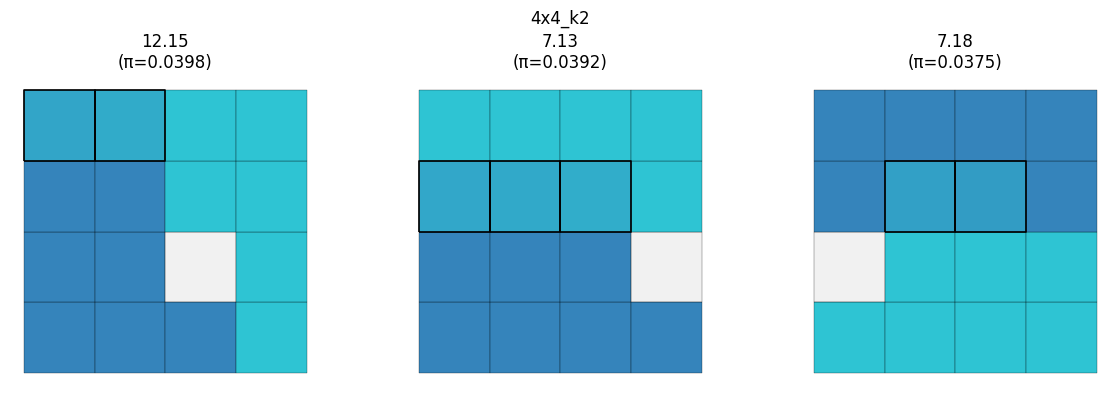

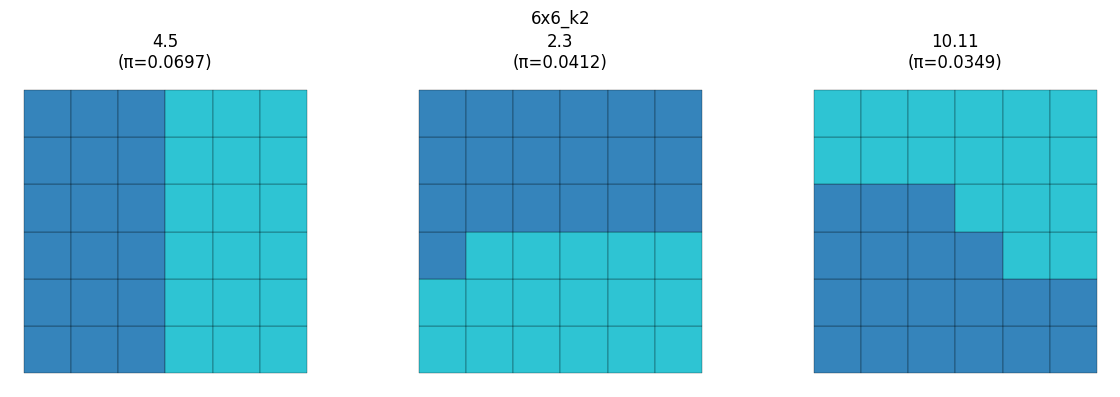

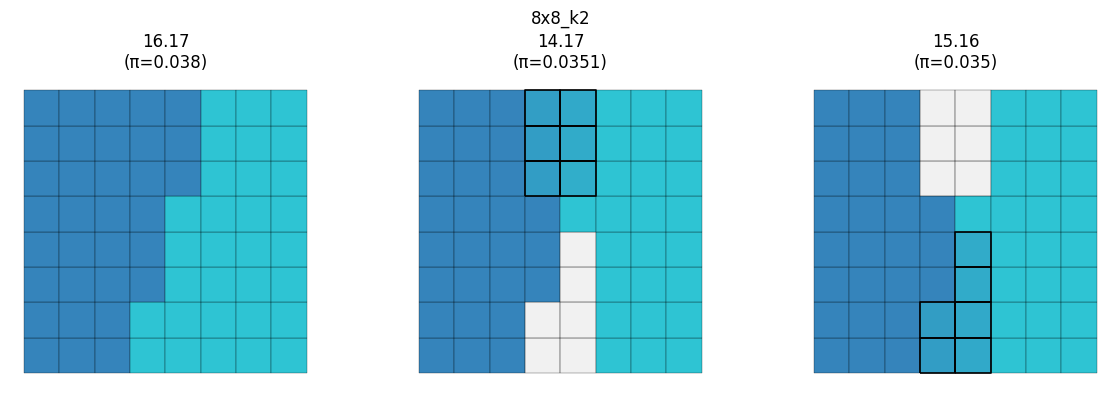

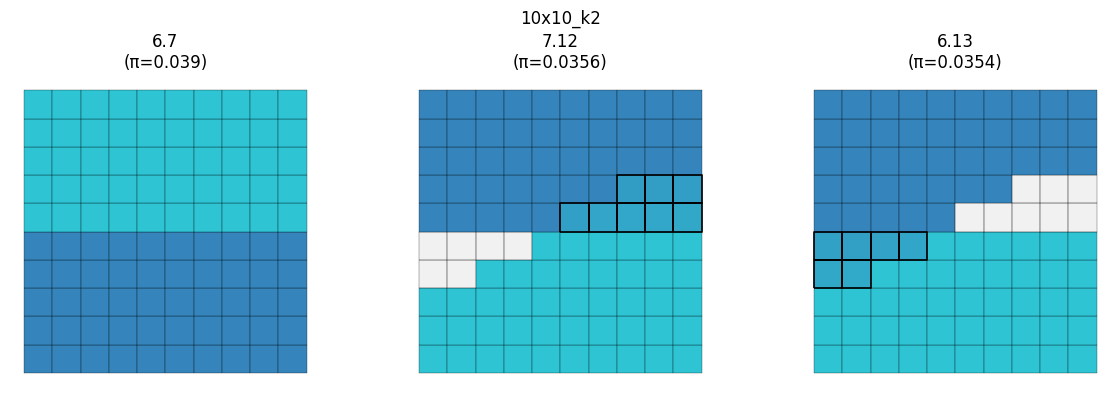

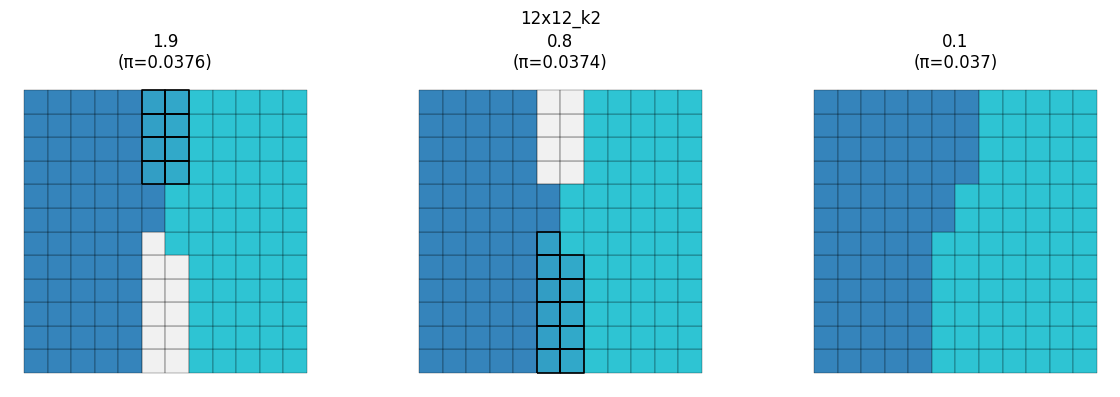

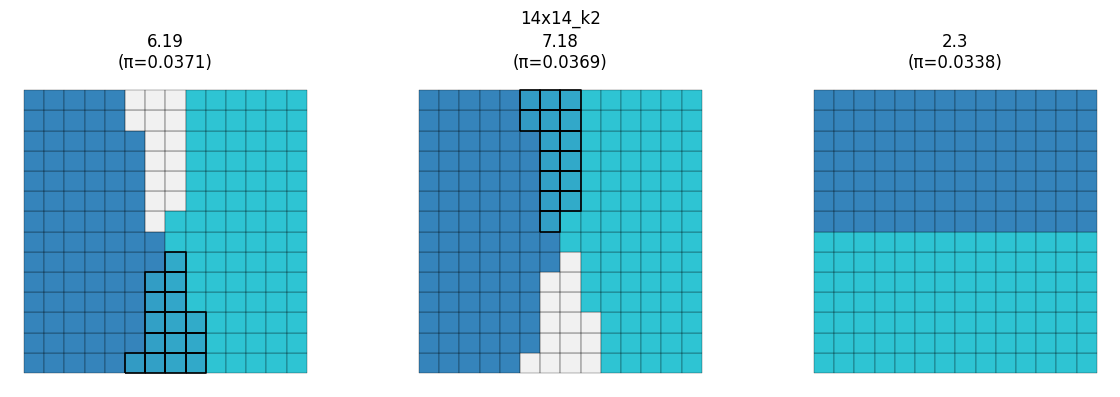

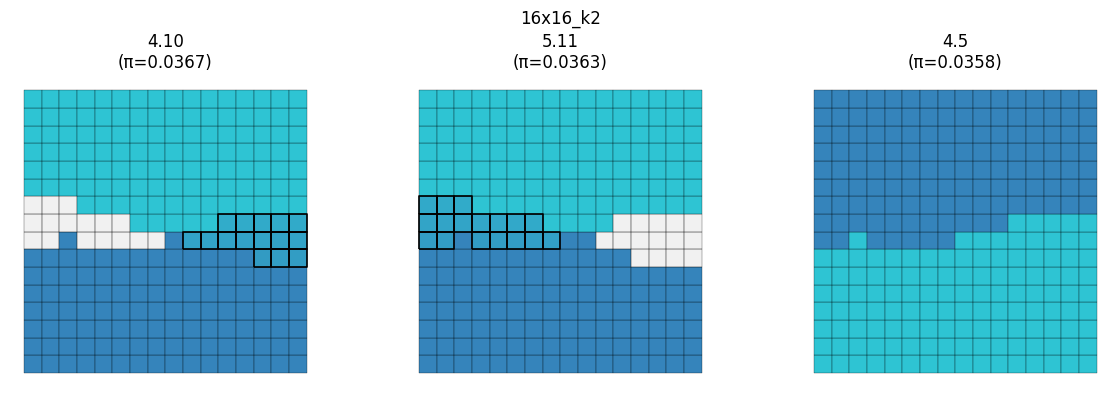

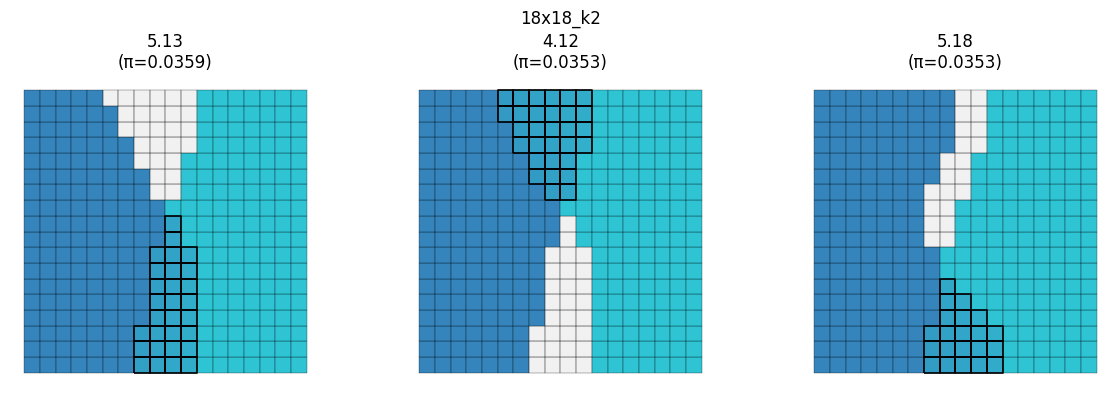

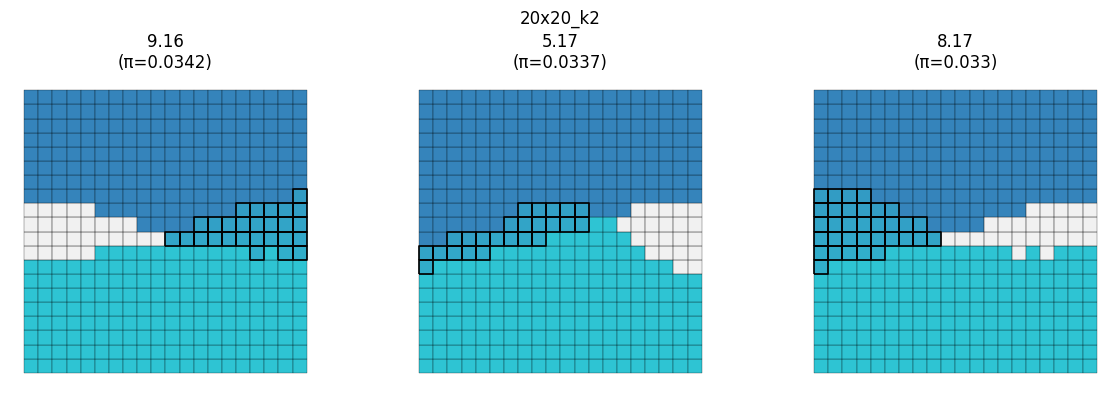

In [13]:
from utils import plot_words_centroids

TOP_VIZ = 3

for N, k in CONFIGS:
    tag = f"{N}x{N}_k{k}"
    r   = results[tag]
    ws  = r["ws"]
    hc  = r["hc"]
    gdf = generate_grid_shape(N)

    df_top = ws.stationary_table().head(TOP_VIZ).reset_index(drop=True)
    fig, axes = plt.subplots(1, TOP_VIZ, figsize=(4 * TOP_VIZ, 4))
    fig.suptitle(tag)
    for i, row in df_top.iterrows():
        ax = axes[i] if TOP_VIZ > 1 else axes
        plot_words_centroids(gdf, hc.cluster_densities, row.word, ltr=True, ax=ax)
        ax.set_title(f"{row.word_str}\n(π={row.stationary:.3g})")
    plt.tight_layout()
    plt.show()

## Step 7 — Flux matrices

/Users/ag245/Library/CloudStorage/GoogleDrive-annacgilbert@gmail.com/My Drive/Research/gmstrat/word.py:378: RuntimeWarning: invalid value encountered in divide
  flux = flux / stationary_matrix


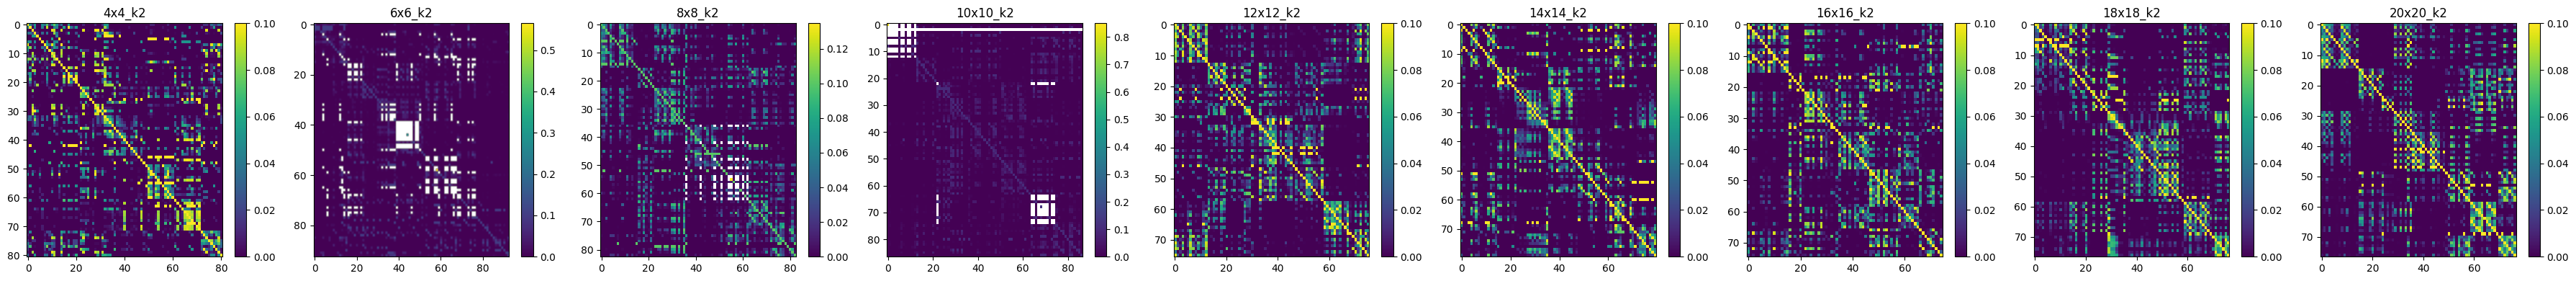

In [14]:
ncols = len(CONFIGS)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

for ax, (N, k) in zip(axes, CONFIGS):
    tag = f"{N}x{N}_k{k}"
    ws  = results[tag]["ws"]
    im  = ax.imshow(ws.flux_matrix(), aspect="auto")
    ax.set_title(tag)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()